# Data Augmentation

In [1]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import random
import yaml
import shutil
from PIL import Image
import pandas as pd

### Funciones necesarias

In [2]:
def find_folder(path):
    return os.path.basename(os.path.dirname(path))

### Carga de datos almacenados

In [3]:
def dataset_already_exists(path_to_check: str) -> bool | None:
    """
    Verifica si el directorio especificado existe y está vacío.

    Args:
        path_to_check (str): Ruta del directorio a verificar.

    Returns:
        bool: True si el directorio existe y está vacío, False en caso contrario.
    """
    if not os.path.exists(path_to_check):
        # El directorio no existe -> Crea el directorio
        #print(f"☑️ El directorio no existe, aún no ha sido creado:\n > {path_to_check}") # Debugging
        return False # No realiza ninguna acción
    else:
        # Verificar si el directorio está vacío
        try:
            # Explora el contenido del directorio
            content = os.listdir(path_to_check)
            #print(content) # Debugging

            # Si el directorio está vacío, se puede eliminar directamente
            #       -> Elimina sin confirmación
            if not content:
                os.rmdir(path_to_check) # Elimina el directorio vacío
                print(f"☑️ El directorio estaba vacío y se ha eliminado de forma automática:\n > {path_to_check}\n")
                return False
            
            # Si el directorio contiene sólo archivos ocultos (de sistema)
            #       -> Elimina sin confirmación
            elif all([file.startswith('.') for file in content]):
                shutil.rmtree(path_to_check) # Elimina el directorio y su contenido
                print(f"☑️ El directorio sólo contenía archivos ocutlos, por lo que se ha eliminado de forma automática:\n > {path_to_check}\n")
                return False

            # Si hay archivos visibles en el directorio (dataset ya existe)
            #       -> Solicita permiso para eliminarlos
            else:
                # Input de confirmación del usuario
                confirmacion = input(f"⚠️ El directorio especificado ya existe y contiene archivos. ¿Deseas eliminar todo su contenido y el directorio en sí? [Y/N]: '{path_to_check}'").strip().lower()
                # Verifica la respuesta del usuario
                if confirmacion == 'y':
                    shutil.rmtree(path_to_check) # Elimina el directorio y su contenido
                    print(f"✅ El directorio y su contenido han sido eliminados exitosamente:\n > {path_to_check}\n")
                    return False
                else:
                    print(f"⛔️ La eliminación del directorio ha sido denegada por el usuario:\n  > {path_to_check}")
                    return True
        
        except OSError as e:
            print(f"❌ Error al eliminar el directorio vacío en {path_to_check}: {e}\n")
            return None
        except Exception as e:
            print(f"‼️ Ocurrió un error inesperado al intentar eliminar el directorio vacío en {path_to_check}: {e}\n")
            return None
        


In [4]:
# Cargamos el dataframe desde el .CSV y definimos 'id' como índice
try:
    df_split = pd.read_csv('dataframe_splitted.csv').set_index('id')
except FileNotFoundError:
    print(f"Error: El archivo 'dataframe.csv' no se encontró en la ubicación actual: {os.getcwd()}")
    print("Se creará nuevamente al correr las celdas de 'Importación de imágenes'.")
    df_split = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo CSV: {e}")
    df_split = None

In [5]:
# Cargar variables desde el archivo YAML
try:
    # Verificar si el archivo YAML existe
    yaml_filename = "constants.yaml"
    with open(yaml_filename, "r") as yaml_file:
        constants_data = yaml.safe_load(yaml_file)

    # Acceder a las variables
    ROOT_DIR = constants_data.get("ROOT_DIR")
    DATASETS_ROOT = constants_data.get("DATASETS_ROOT")
    DATASET_PATH = constants_data.get("DATASET_PATH")
    SPLITTED_PATH = constants_data.get("SPLITTED_PATH")

    print(f"✅ Se han cargado las variables de configuración desde '{yaml_filename}'")
    print(f" - ROOT_DIR: {ROOT_DIR}")
    print(f" - DATASETS_ROOT: {DATASETS_ROOT}")
    print(f" - DATASET_PATH: {DATASET_PATH}")
    print(f" - SPLITTED_PATH: {SPLITTED_PATH}")
except FileNotFoundError:
    print(f"Error: El archivo 'constants.yaml' no se encontró en la ubicación actual: {os.getcwd()}")
    print("Se creará nuevamente al correr el notebook.")
    ROOT_DIR = None
    DATASETS_ROOT = None
    DATASET_PATH = None
    SPLITTED_PATH = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo YAML: {e}")

✅ Se han cargado las variables de configuración desde 'constants.yaml'
 - ROOT_DIR: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color
 - DATASETS_ROOT: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/
 - DATASET_PATH: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
 - SPLITTED_PATH: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/splitted/


In [6]:
# Carga de imagenes en memoria y visualización
def load_image(data: pd.DataFrame, index: int, root: str=ROOT_DIR):
    """
    Carga una imagen PIL desde una fila específica de un DataFrame.

    Args:
        dataframe (pandas.DataFrame): El DataFrame que contiene las rutas de las imágenes.
        index (int): El índice de la fila en el DataFrame para cargar la imagen.
        root_dir (str): El directorio raíz donde se encuentran las imágenes.

    Returns:
        PIL.Image.Image: La imagen cargada como un objeto PIL.Image, o None si ocurre un error.
    """
    # if index < 0 or index >= len(data):
    #     print("Índice fuera de rango.")
    #     return None

    row = data.iloc[index]
    relative_path = row['image_path']
    filename = row['filename']
    full_path = os.path.join(root, relative_path, filename)

    try:
        img = Image.open(full_path)
        return img
    except FileNotFoundError:
        print(f"Archivo no encontrado: {full_path}")
        return None
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return None

In [7]:
ROOT_DIR

'/Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color'

In [8]:
# Carga de imagenes en memoria y visualización
def load_image_idx(data, root: str=ROOT_DIR):
    """
    Carga una imagen PIL desde una fila específica de un DataFrame.

    Args:
        dataframe (pandas.DataFrame): El DataFrame que contiene las rutas de las imágenes.
        index (int): El índice de la fila en el DataFrame para cargar la imagen.
        root_dir (str): El directorio raíz donde se encuentran las imágenes.

    Returns:
        PIL.Image.Image: La imagen cargada como un objeto PIL.Image, o None si ocurre un error.
    """
    # if index < 0 or index >= len(data):
    #     print("Índice fuera de rango.")
    #     return None

    row = data
    relative_path = row['image_path']
    filename = row['filename']
    full_path = os.path.join(root, relative_path, filename)

    try:
        img = Image.open(full_path)
        return img
    except FileNotFoundError:
        print(f"Archivo no encontrado: {full_path}")
        return None
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return None

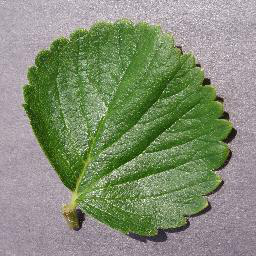

In [9]:
# Permite visualizar una imagen específica (con iloc)
id = 0 # Indice de la imagen a cargar
image = load_image(data=df_split, index=id, root=ROOT_DIR)

#image.show() #popup option
image

---
# Experimentación

## Transformaciones

In [10]:
# 1. Define las transformaciones de Albumentations
transform = A.Compose([
    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5
    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5
    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano
    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%
])

In [11]:
"""
TRANSFORMACIONES ALBUMENTATION:
    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5
    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5
    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano
    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%
    A.AdditiveNoise(p=0.2), # Ruido aditivo
    A.CLAHE(clip_limit=2.0, p=0.3),             # Ecualización CLAHE
    A.Resize(height=256, width=256, p=1),      # Redimensionamiento a 256x256
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), p=1), # Normalización
    A.AdvancedBlur(blur_limit=(3, 7), p=0.2), # Desenfoque avanzado
    A.RandomGridShuffle(grid=(2, 2), p=0.3), # Mezcla de rejilla aleatoria
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
"""

'\nTRANSFORMACIONES ALBUMENTATION:\n    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5\n    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5\n    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5\n    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio\n    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor\n    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200\n    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano\n    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%\n    A.AdditiveNoise(p=0.2), # Ruido aditivo\n    A.CLAHE(clip_limit=2.0, p=0.3),             # Ecualización CLAHE\n    A.Resize(height=256, width=256, p=1),      # Redimensionamiento a 256x256\n    A.Norma

In [12]:
def apply_transformations(original_image):
    # Convertir la imagen original a un array NumPy para la transformación
    original_image_array = np.array(original_image)

    # Aplicar las transformaciones
    transformed = transform(image=original_image_array)
    return transformed['image']

## Visualización

Visualizando imágenes originales y transformadas (5 muestras):
Muestra #1 (Índice: 45422):


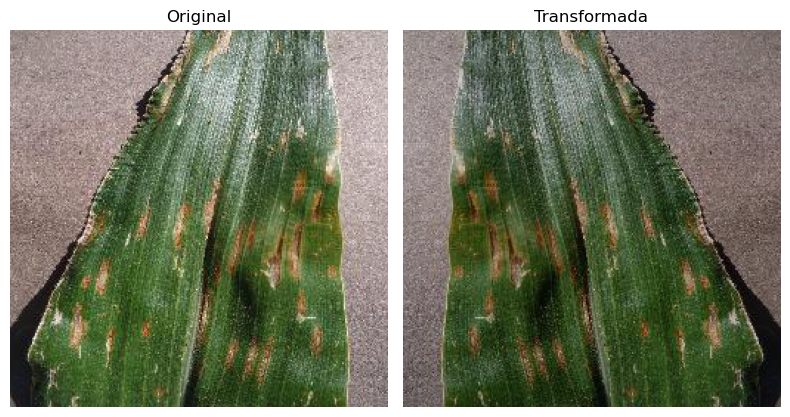

Muestra #2 (Índice: 53828):


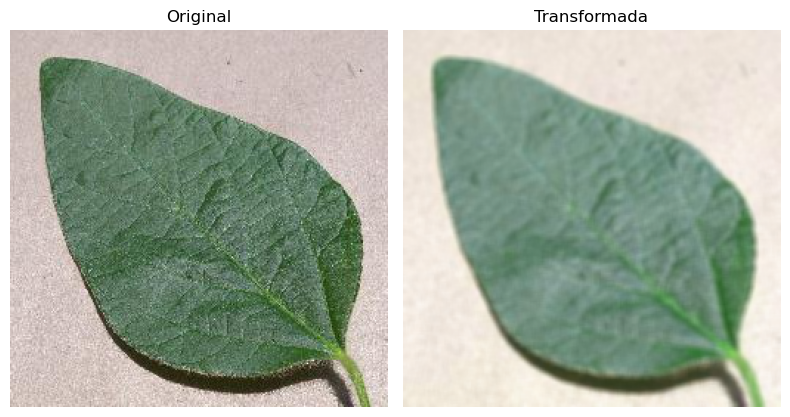

Muestra #3 (Índice: 1310):


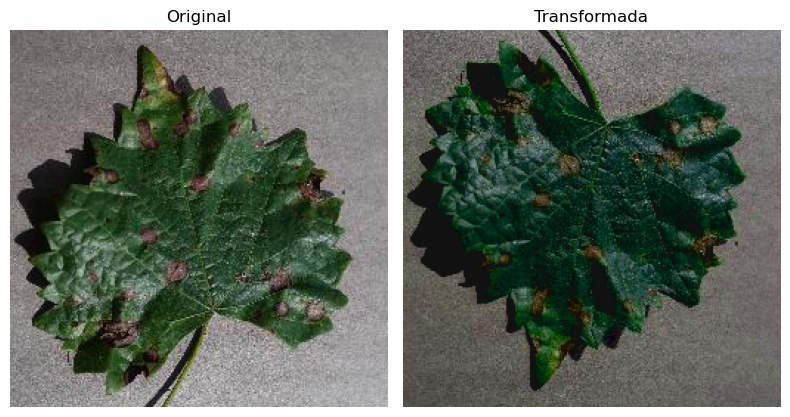

Muestra #4 (Índice: 23776):


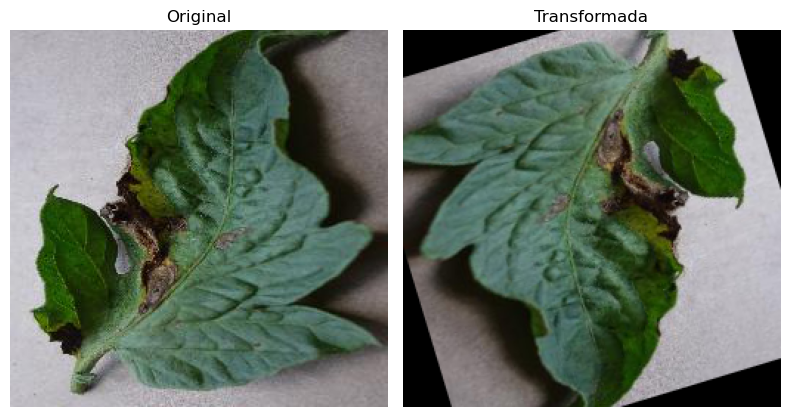

Muestra #5 (Índice: 33513):


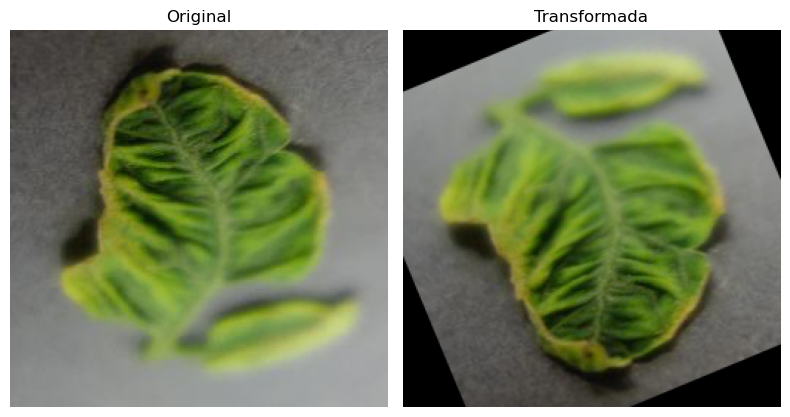

In [28]:
num_to_display = 5  # Reducir para mejor visualización en el gráfico
random_indices = random.sample(range(len(df_split)), num_to_display)

print(f"Visualizando imágenes originales y transformadas ({num_to_display} muestras):")
for i, index in enumerate(random_indices):
    try:
        original_image = load_image(data=df_split, index=index, root=ROOT_DIR)
        print(f"Muestra #{i+1} (Índice: {index}):")

        # Convertir la imagen original a un array NumPy para la transformación
        original_image_array = np.array(original_image)

        # Aplicar las transformaciones
        transformed = transform(image=original_image_array)
        transformed_image_array = transformed['image']

        fig, axes = plt.subplots(1, 2, figsize=(8, 5))

        # Mostrar la imagen original en el primer subplot (izquierda)
        axes[0].imshow(original_image_array)
        axes[0].set_title('Original')
        axes[0].axis('off')  # Ocultar los ejes

        # Mostrar la imagen transformada en el segundo subplot (derecha)
        axes[1].imshow(transformed_image_array)
        axes[1].set_title('Transformada')
        axes[1].axis('off')  # Ocultar los ejes

        plt.tight_layout()  # Ajustar el espaciado entre subplots para evitar superposiciones
        plt.show()

    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en la ruta: {os.path.join(ROOT_DIR, df_split.loc[index, 'relative_path'])}")
    except Exception as e:
        print(f"Error al cargar la imagen en el índice {index}: {e}")

----
# Procesamiento del dataset

## Creación de directorios y estructuras de datos

Primero, se realiza una copia del dataset original (splitteado) a un nuevo directorio, donde luego serán procesadas las imágenes para la aumentación.

In [182]:
verfication = True # Ejecuta el proceso de verificación (punto 2)

print(f"Se inicia proceso de copiado del dataset…")
total_files = len(df_split) # Total de archivos del dataset
print(f" - Total de archivos en el dataset: {total_files}\n")

# Realiza el proceso de copiado de archivos para cada split
succeeded_process = True

# Crea las rutas de origen y destino
source_folder = f'{SPLITTED_PATH}/'
destination_folder = f'{DATASETS_ROOT}augmented/'
if dataset_already_exists(destination_folder): # Verifica si el directorio existe y está vacío
    print("  ⨯ El directorio ya existe y contiene archivos, a petición del usuario se omite el proceso de copiado.")
    pass # Si el directorio ya existe, no se hace nada+
else:
    print(f"🔄 Procesando dataset '{find_folder(SPLITTED_PATH)}':")

    try:
        print(f"1. Creando estructura de subcarpetas:")
        # 1. Crea la función para ignorar específica para el split a procesar
        

        # 2. Con copytree copia todo el "árbol" de directorios (careptas y subcarpetas)
        # Fitrando con ignore_function todos aquellos archivos que no pertenecen al split deseado
        print(f"    ∞ Copiando contenido del dataset (puede demorar hasta un minuto).")
        shutil.copytree(source_folder, destination_folder)
        print(f"    ✔ Proceso de copiado del split finalizado.")

        if verfication:
            # Verifica qué se haya copiado adecuadamente (opcional pero útil)
            print(f"2. Se inicia proceso de verificación…")
            copied_files = []
            for root, dirs, files_in_dest in os.walk(destination_folder):
                for name in files_in_dest:
                    copied_files.append(os.path.join(os.path.relpath(root, destination_folder), name).replace('\\', '/')) # Normalizar path
                    #print(f"  - {os.path.join(root, name)}") # Debuggin
            print(f"    ✔ Se crearon un total de {len(os.listdir(destination_folder))} carpetas (para los splits).")
            print(f"    ✔ Se copiaron un total de {len(copied_files)} archivos ({len(copied_files)/total_files*100:.2f}%)")
    
    except FileExistsError:
        print(f"Error: La carpeta de destino '{destination_folder}' ya existe.\n")
        pass
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}\n")

    finally:
        print("\n🌟 El proceso de copiado del dataset ha finalizado con éxito.\n")
        AUG_PATH = destination_folder

time.sleep(15) # Agrega un delay de 30seg para asegurar que el SO termine el copiado


Se inicia proceso de copiado del dataset…
 - Total de archivos en el dataset: 54305

✅ El directorio y su contenido han sido eliminados exitosamente:
 > /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/augmented/

🔄 Procesando dataset 'splitted':
1. Creando estructura de subcarpetas:
    ∞ Copiando contenido del dataset (puede demorar hasta un minuto).
    ✔ Proceso de copiado del split finalizado.
2. Se inicia proceso de verificación…
    ✔ Se crearon un total de 3 carpetas (para los splits).
    ✔ Se copiaron un total de 54308 archivos (100.01%)

🌟 El proceso de copiado del dataset ha finalizado con éxito.



In [183]:
# Se ha definido una nueva constante con la ubicación del dataset aumentado (será almacenadad en YAML)
AUG_PATH

'/Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/augmented/'

Luego, se aplican las transformaciones para aumentación de datos a la copia del dataset.

In [184]:
# Agrega columnas para indicar procesamiento
## original -> imagen sin transofrmaciones
## augmented -> existen aumentaciones derivadas
df_split['augmented'] = False
df_split['is_original'] = True

# Crea un nuevo dataframe para gesitonar el procesamiento
process_split = df_split[df_split['split']=='train'].copy()
process_split

,image_path,filename,class,group,tag,split,augmented,is_original
id,,,,,,,,
0,Strawberry___healthy/,8f558908-aa1b-4a86-855a-5094c2392e5a___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True
2,Strawberry___healthy/,abdd34a0-ab02-41e0-95a3-a014ab863ec2___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True
3,Strawberry___healthy/,d1aee44a-b6bb-45b9-b7b6-5d553add8fd1___RS_HL 2...,Strawberry___healthy,Strawberry,healthy,train,False,True
4,Strawberry___healthy/,3d28c3ea-8419-4e09-addd-211e3828e39f___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True
5,Strawberry___healthy/,4005fb13-0d7c-4a30-9ee3-73e9e4cee05e___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True
...,...,...,...,...,...,...,...,...
54299,Soybean___healthy/,39d15a45-c9f2-4933-b31e-fde13e0141b1___RS_HL 2...,Soybean___healthy,Soybean,healthy,train,False,True
54300,Soybean___healthy/,57c18b39-2a33-471f-91eb-a9ba4ddabc7b___RS_HL 6...,Soybean___healthy,Soybean,healthy,train,False,True
54301,Soybean___healthy/,4fdc663e-a8ea-4d8a-801b-ef18ad192661___RS_HL 6...,Soybean___healthy,Soybean,healthy,train,False,True


In [185]:
# Crea una columna 'ref' que apunta al id de la imagen original
process_split['ref'] = process_split.index
process_split

,image_path,filename,class,group,tag,split,augmented,is_original,ref
id,,,,,,,,,
0,Strawberry___healthy/,8f558908-aa1b-4a86-855a-5094c2392e5a___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True,0
2,Strawberry___healthy/,abdd34a0-ab02-41e0-95a3-a014ab863ec2___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True,2
3,Strawberry___healthy/,d1aee44a-b6bb-45b9-b7b6-5d553add8fd1___RS_HL 2...,Strawberry___healthy,Strawberry,healthy,train,False,True,3
4,Strawberry___healthy/,3d28c3ea-8419-4e09-addd-211e3828e39f___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True,4
5,Strawberry___healthy/,4005fb13-0d7c-4a30-9ee3-73e9e4cee05e___RS_HL 1...,Strawberry___healthy,Strawberry,healthy,train,False,True,5
...,...,...,...,...,...,...,...,...,...
54299,Soybean___healthy/,39d15a45-c9f2-4933-b31e-fde13e0141b1___RS_HL 2...,Soybean___healthy,Soybean,healthy,train,False,True,54299
54300,Soybean___healthy/,57c18b39-2a33-471f-91eb-a9ba4ddabc7b___RS_HL 6...,Soybean___healthy,Soybean,healthy,train,False,True,54300
54301,Soybean___healthy/,4fdc663e-a8ea-4d8a-801b-ef18ad192661___RS_HL 6...,Soybean___healthy,Soybean,healthy,train,False,True,54301


## Estrategia de aumentación

Dado que el dataset original está desbalanceado, se aplicará la aumentación de datos sólo a las clases minoritarias como forma de compensar el desbalance.

In [186]:
### Resumen distribucion por grupo
print("Conteo por grupo:")
print(df_split['group'].value_counts())
#df_split['class'].value_counts()

Conteo por grupo:
group
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64


In [187]:
def filter_classes(df, range: tuple = (0,None)):
    lim_min, lim_max = range
    counts = df['group'].value_counts()
    if lim_min == None:
        lim_min  = 0
    if lim_max == None:
        lim_max  = counts.max()
    #print("Limites:", lim_min, lim_max)

    selection = []
    for idx, count in enumerate(counts):
        if lim_min < count <= lim_max:
            clase = counts.index[idx]
            selection.append(clase)
    return selection

In [188]:
def numoji(numero):
  """
  Convierte un número entero del 1 al 10 a su emoji correspondiente.

  Args:
    numero: Un entero entre 1 y 10.

  Returns:
    Un string con el emoji correspondiente al número, o "0️⃣" si el número
    está fuera del rango.
  """
  if 1 <= numero <= 10:
    emoji_map = {
        1: "1️⃣",
        2: "2️⃣",
        3: "3️⃣",
        4: "4️⃣",
        5: "5️⃣",
        6: "6️⃣",
        7: "7️⃣",
        8: "8️⃣",
        9: "9️⃣",
        10: "🔟"
    }
    return emoji_map[numero]
  else:
    return "*️⃣"

In [189]:
# Clases a las que se le aplicará aumentación de datos
# Entre 4000 y 2000
group1 = {
    'classes': filter_classes(df_split,(2000,4000)),
    'increase': 2 # 2x data augmentation (original + transf)
}
# Menores a 2000
group2 = {
    'classes': filter_classes(df_split,(500,2000)),
    'increase': 3 # 3x data augmentation (original +  2 transf)
}

# Clase mínima (Raspberry)
group3 = {
    'classes': filter_classes(df_split,(0,500)),
    'increase': 6 # 6x data augmentation (original +  5 transf)
}

In [190]:
print("Efecto de la aumentación de datos para 'train' split\n")
counts = df_split[df_split['split']=='train']['group'].value_counts()

groups = [group1, group2, group3]
for group in groups:
    mult = group['increase']
    print(f"Estrategia de aumentación {mult}x:")
    for clase in group['classes']:
        print(f" - {clase}: {counts[clase]} -> {counts[clase]*mult}")
    print()

Efecto de la aumentación de datos para 'train' split

Estrategia de aumentación 2x:
 - Corn_(maize): 3081 -> 6162
 - Apple: 2537 -> 5074
 - Peach: 2125 -> 4250
 - Pepper,_bell: 1980 -> 3960
 - Potato: 1722 -> 3444

Estrategia de aumentación 3x:
 - Cherry_(including_sour): 1525 -> 4575
 - Squash: 1468 -> 4404
 - Strawberry: 1252 -> 3756
 - Blueberry: 1202 -> 3606

Estrategia de aumentación 6x:
 - Raspberry: 297 -> 1782



In [191]:
def gen_rnd_id():
    """
        Genera un número aleatorio de 6 cífras que se usará para diferenciar imagenes procesados de las originales
    """
    rnd_seed = round(time.time() * 1e10) # Use clock as seed generator
    random.seed(rnd_seed)  # Set this value as a new seed (assure better randomization)
    sampled_numbers = random.sample(range(int(1e6)), 1)  # Generates a random number
    return sampled_numbers[0]

In [192]:
import humanize

# Traducir humanize al español
try:
    humanize.i18n.activate("es") 
except FileNotFoundError:
    print("Paquete de idioma español para humanize no encontrado, usando inglés.")
    humanize.i18n.activate("en_US") # Fallback a inglés

In [193]:
# PROCESAMIENTO DE AUMENTACIONES CON FILTRADO POR CLASE
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SETUP INCIAL:
verbose = True # Incluye detalle del proceso y estimación de tiempo
testing = False # No modifica archivos 
debugging = False # Incluye detalle de archivos y mensajes de error
processes = [group1, group2, group3] # Estrategias a aplicar
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for_processing_classes = [cls for group in groups for cls in group['classes']]
for_processing_data = process_split[process_split['group'].isin(for_processing_classes)]

print(f"Iniciando proceso de aumentación de datos…")
folder = f'{AUG_PATH}train/'
print(f"Aumentando imágenes para:\n >>", folder)
total_files = len(for_processing_data) # Total de archivos del dataset
print(f" - Total de archivos en el dataset 'train': {len(process_split)}")
print(f" - Total de archivos en a aumentar: {total_files} ({(total_files/len(process_split)*100):.0f}% del dataset)\n")
print(f"Se procesarán un total de {len(for_processing_classes)} clases de {len(process_split['group'].value_counts())}:")
for label in for_processing_classes:
    print(" - ",label)
print()
for i, process in enumerate(processes):
    print(f"· Estrategia {i+1}: {process['increase']}x aumentation para {process['classes']}")
print("\n¿Deseas iniciar el procesamiento?")

# Input de confirmación del usuario
confirmacion = input(f"⚠️ ATENCIÓN: El proceso puede demorar varios minutos. Se requiere confirmación para continuar [Y/N]: ").strip().lower()
if confirmacion != 'y':
    print(f"\n⛔️ La ejecución ha sido denegada por el usuario.")
else:
    start_time = time.perf_counter() # Medición del tiempo

    # PROCESAMIENTO DE AUMENTACIONES
    # Leyenda:
    #  count -> archivos originales procesados (total)
    #  work -> transformaciones por clase (parcial)
    #  task -> número de transformaciones por archivo

    # Duplica dataframe para almacenar el proceso
    processed_split = process_split.copy()

    # Realiza el proceso de copiado de archivos para cada grupo
    succeeded_process = True
    count = 0
    avg_time = 0
    partial_time = 0
    previous_count = 0
    spacer1 = '   '
    spacer2 = '      '

    for i, process in enumerate(processes):
        mult = process['increase']
        n_aumentations = mult - 1 # se resta 1 porque la imagen original ya existe
        classes = process['classes']
        print(f"\n\n{numoji(i+1)} Iniciando subproceso de aumentación:")
        print(f" - Estrategia de aumentación: {mult}x")
        print(f" - Clases a procesar: {len(classes)} grupos\n   {classes}")

        for clase in classes:
            # Filtrado de clases
            subprocess_split = process_split[process_split['group']==clase]
            total_work = len(subprocess_split) * n_aumentations # Conteo de archivos para la clase
            print(f"\n{spacer1}🔄 Procesando clase '{clase}' ({(total_work/total_files*100):.0f}% del total):")
            print(f"{spacer1}  - Transformaciones a generar: {total_work}") if verbose else None
            work = 0
 
            for index, image_row in subprocess_split.iterrows():
                if work==0 and testing:
                    print(f"{spacer2}(+) TESTING: omite la apertura de la imagen.")
                    print(f"{spacer2}(+) TESTING: omite las transformaciones.")
                # 1. Apertura del archivo de imagen original
                original_image = load_image_idx(data=image_row,root=folder) if not testing else None
                #original_image.show() # Debugging

                # Genera múltiples transformaciones para cada imagen
                try:
                    task = n_aumentations
                    for n in range(n_aumentations):

                        # 2. Procesamiento de la transformacion
                        transformed_image = apply_transformations(original_image) if not testing else None
                        try:
                            # Convierte el array NumPy a un objeto Image de PIL
                            if not testing:
                                if transformed_image.ndim == 2:  # Escala de grises
                                    processed_image = Image.fromarray(transformed_image.astype(np.uint8), 'L')
                                elif transformed_image.ndim == 3:  # RGB
                                    if transformed_image.shape[2] == 3:
                                        processed_image = Image.fromarray(transformed_image.astype(np.uint8), 'RGB')
                                    else:
                                        raise ValueError(f"{spacer2}❗️El array NumPy debe tener 2 (escala de grises) o 3 (RGB) canales.")
                                else:
                                    raise ValueError(f"{spacer2}❗️ El array NumPy debe tener 2 o 3 dimensiones.")
                                #processed_image.show() # Debugging
                                
                            # 3. Almacena el archivo
                            # Genera el nombre del nuevo archivo
                            # se incluye un int random al final (para permitir múltiples aumentaciones)
                            rnd_num = str(gen_rnd_id()).zfill(6) # string de 6 cifras
                            name = list(os.path.splitext(image_row.filename))
                            name.insert(1,f'-{rnd_num}')
                            filename = "".join(name)
                            # Guarda la transformación como JPG
                            processed_image.save(f'{folder}{image_row.image_path}{filename}', "JPEG") if not testing else None
                            print(f"{spacer2}🔹 {filename}") if debugging else None

                            # 4. Registra la nueva imagen en el DataFrame
                            new_row = image_row.copy() # Copia las etiquetas
                            # Actualiza los valores correspondientes
                            new_row['filename'] = filename
                            new_row['is_original'] = False
                            new_row['augmented'] = True
                            # Agrega la nueva fila al DataFrame processed_split
                            processed_split = pd.concat([processed_split, pd.DataFrame([new_row])], ignore_index=True)
                            
                            task -= 1 # cuenta una transformación finalizada
                            work += 1 # cuenta una aumentación realizada (por clase)
                            if work % 100 == 0:
                                print(f'{spacer2}🔨 » Progreso subproceso: {work/total_work*100:.2f}%') if verbose else None

                        except FileExistsError:
                            print(f"{spacer2}❌ Error: El archivo de destino '{destination_folder}' ya existe.\n") if debugging else None
                            continue
                        except Exception as e:
                            print(f"{spacer2}❌ Error al guardar la imagen como JPG: {e}") if debugging else None
                            continue
                finally:
                    # 5. Actualiza el registro de la imagen original
                    processed_split.loc[index, 'augmented'] = True
                    #print(processed_split.iloc[index])      
                          
                    count += 1 # cuenta un archivo finalizado
                    if task == 0:
                        pass
                    else:
                        print(f"{spacer2}‼️ ALERTA: No se ha completado la tarea para {image_row.filename}")

                
            print(f'{spacer2}🔨 » Progreso subproceso: 100%') if verbose else None
            
            # LÓGICA TEMPORAL
            if verbose:
                # Medición de tiempo pasado y estimación del faltante
                previous_time = partial_time
                partial_time = time.perf_counter() # Medición del tiempo
                divisor = count - previous_count
                task_time = (partial_time - previous_time)/divisor
                elapsed_time = (partial_time - start_time)
                avg_time = elapsed_time/count # Tiempo medio para estimación

                print(f'{spacer2}⏱️ · Tiempo de suproceso {humanize.naturaldelta(avg_time)}')
                if previous_count and verbose:
                    if task_time > avg_time*1.1:
                        print(f"{spacer2}👎🏻 La tarea ha demorado más de lo esperado…")
                    elif task_time < avg_time*0.75:
                        print(f"{spacer2}👍🏻 ¡Tarea completada en tiempo record!")

            if work == total_work:
                print(f"{spacer1}✅ Subproceso de transfromaciones completado.")
                succeeded = True
            else:
                print(f"{spacer1}‼️ ALERTA: No se pudo completar correctamente el subproceso de transfromaciones.")
                succeeded = False
            if verbose:
                #print(f'\n{spacer1}🕗 Ejecución total {elapsed_time/60:.1f} min')
                print(f'\n{spacer1}🕗 Ejecución total {humanize.naturaldelta(elapsed_time)}')
                #print(f'{spacer1}🔮 Estimación de tiempo restante {(avg_time * (len(for_processing_classes) - count)) / 60:.2f} min')
                print(f'{spacer1}🔮 Estimación de tiempo restante {humanize.naturaldelta((avg_time * (len(for_processing_classes) - count)))}')
                print(f'{spacer1}❇️ » Progreso general: {count/total_files*100:.3f}%')
            previous_count = count

            succeeded_process *= succeeded # Actualiza el estado del proceso
            # (Sólo es 'True' si todos los subprocesos se completan correctamente)

    print(f'{spacer1}❇️ » Progreso general: 100%') if not testing else None
    if succeeded_process:
        print("\n🌟 El proceso de aumentación del dataset ha finalizado con éxito.")
    else:
        print("\n🚫 No se pudo completar satisfactoriamente el proceso de aumentación del dataset.")

Iniciando proceso de aumentación de datos…
Aumentando imágenes para:
 >> /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/augmented/train/
 - Total de archivos en el dataset 'train': 43444
 - Total de archivos en a aumentar: 17189 (40% del dataset)

Se procesarán un total de 10 clases de 14:
 -  Corn_(maize)
 -  Apple
 -  Peach
 -  Pepper,_bell
 -  Potato
 -  Cherry_(including_sour)
 -  Squash
 -  Strawberry
 -  Blueberry
 -  Raspberry

· Estrategia 1: 2x aumentation para ['Corn_(maize)', 'Apple', 'Peach', 'Pepper,_bell', 'Potato']
· Estrategia 2: 3x aumentation para ['Cherry_(including_sour)', 'Squash', 'Strawberry', 'Blueberry']
· Estrategia 3: 6x aumentation para ['Raspberry']

¿Deseas iniciar el procesamiento?


1️⃣ Iniciando subproceso de aumentación:
 - Estrategia de aumentación: 2x
 - Clases a procesar: 5 grupos
   ['Corn_(maize)', 'Apple', 'Peach', 'Pepper,_bell', 'Potato']

   🔄 Procesando clase 'Corn_(maize)' (18% del total):
     - Trans

El script realiza 1000 transformaciones en ~0.16 seg.
Para procesar 17k imágenes debería demorar 2.79 min

In [194]:
# PROCESAMIENTO DE AUMENTACIONES PARA TODO EL DATASET
"""
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SETUP INCIAL:
n_aumentations = 2
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Se inicia proceso de copiado del dataset…")
total_files = len(process_split) * n_aumentations # Total de archivos del dataset
print(f" - Total de archivos en el dataset: {total_files}")
folder = f'{AUG_PATH}train/'
print(f"Aumentando imágenes de:\n >>", folder)

# Duplica dataframe para almacenar el proceso
processed_split = process_split.copy()
#processed_split = pd.DataFrame(columns=process_split.columns.tolist())

# Realiza el proceso de copiado de archivos para cada split
succeeded_process = True
count = 0
for index, image_row in process_split.iterrows():
    # 1. Apertura del archivo de imagen original
    original_image = load_image_idx(data=image_row,root=folder)
    #original_image.show() # Debugging

    # Genera múltiples transformaciones para cada imagen
    try:
        work = 0
        total_work = 1 * n_aumentations # <<< se inlcuirá conteo de clase
        for n in range(n_aumentations):

            # 2. Procesamiento de la transformacion
            transformed_image = apply_transformations(original_image)
            try:
                # Convierte el array NumPy a un objeto Image de PIL
                if transformed_image.ndim == 2:  # Escala de grises
                    processed_image = Image.fromarray(transformed_image.astype(np.uint8), 'L')
                elif transformed_image.ndim == 3:  # RGB
                    if transformed_image.shape[2] == 3:
                        processed_image = Image.fromarray(transformed_image.astype(np.uint8), 'RGB')
                    else:
                        raise ValueError("El array NumPy debe tener 2 (escala de grises) o 3 (RGB) canales.")
                else:
                    raise ValueError("El array NumPy debe tener 2 o 3 dimensiones.")
                #processed_image.show() # Debugging
                
                # 3. Almacena el archivo
                # Genera el nombre del nuevo archivo
                # se incluye un int random al final (para permitir múltiples aumentaciones)
                rnd_num = str(gen_rnd_id()).zfill(6) # string de 6 cifras
                name = list(os.path.splitext(image_row.filename))
                name.insert(1,f'-{rnd_num}')
                filename = "".join(name)
                
                # Guarda la transformación como JPG
                processed_image.save(f'{folder}{image_row.image_path}{filename}', "JPEG")
                #print(f"Imagen guardada exitosamente como: {filename}")

                # 4. Registra la nueva imagen en el DataFrame
                new_row = image_row.copy() # Copia las etiquetas
                # Actualiza los valores correspondientes
                new_row['filename'] = filename
                new_row['is_original'] = False
                new_row['augmented'] = True
                # Agrega la nueva fila al DataFrame processed_split
                processed_split = pd.concat([processed_split, pd.DataFrame([new_row])], ignore_index=True)
                
                work += 1
                if work % 10 == 0:
                    print(f'Progreso subproceso: {work/total_work:.3f}%')

            except FileExistsError:
                print(f"Error: El archivo de destino '{destination_folder}' ya existe.\n")
                pass
            except Exception as e:
                print(f"Error al guardar la imagen como JPG: {e}")
                pass
    finally:
        # 5. Actualiza el registro de la imagen original
        processed_split.loc[index, 'augmented'] = True
        #print(processed_split.iloc[index])

        count += 1
        if work == total_work:
            print(f"✅ Se completó satisfactoriamente el subproceso de transfromaciones.\n")
            succeeded = True
        else:
            print(f"❌ Error: No se pudo copiar correctamente el subproceso de transfromaciones.\n")
            succeeded = False

    if index % 1000 == 0:
        print(f'Progreso general: {count/total_files:.3f}%')

    # if index >100:
    #     break

    succeeded_process *= succeeded # Actualiza el estado del proceso
    # (Sólo es 'True' si todos los subprocesos se completan correctamente)

if succeeded_process:
    print("\n\n🌟 El proceso de copiado del dataset ha finalizado con éxito.\n")
else:
    print("\n\n🚫 No se pudo completar satisfactoriamente el proceso de copiado del dataset.\nVerificar que se haya completado la eliminación de las carpetas.\n")
"""

'\n#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n# SETUP INCIAL:\nn_aumentations = 2\n#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\nprint(f"Se inicia proceso de copiado del dataset…")\ntotal_files = len(process_split) * n_aumentations # Total de archivos del dataset\nprint(f" - Total de archivos en el dataset: {total_files}")\nfolder = f\'{AUG_PATH}train/\'\nprint(f"Aumentando imágenes de:\n >>", folder)\n\n# Duplica dataframe para almacenar el proceso\nprocessed_split = process_split.copy()\n#processed_split = pd.DataFrame(columns=process_split.columns.tolist())\n\n# Realiza el proceso de copiado de archivos para cada split\nsucceeded_process = True\ncount = 0\nfor index, image_row in process_split.iterrows():\n    # 1. Apertura del archivo de imagen original\n    original_image = load_image_idx(data=image_row,root=folder)\n    #original_image.show() # Debugging\n\n    # Genera múltiples transformaciones para cada imagen\n    try:\n       

# Verificación

Ahora, verificamos el proceso de aumentación.

### Archivos

In [195]:
resut_aug_dataframe = len(processed_split) - len(process_split)
print(f"Luego del proceso de aumentación de datos se genraron {resut_aug_dataframe} archivos nuevos.")

Luego del proceso de aumentación de datos se genraron 23824 archivos nuevos.


In [196]:
def contar_archivos(ruta):
    total = 0
    with os.scandir(ruta) as it:
        for entry in it:
            if entry.is_file():
                total += 1
            elif entry.is_dir():
                total += contar_archivos(entry.path)
    return total

In [197]:
# Verifcamos que el valor coincida con los archivos en las carpetas
aug_len = contar_archivos(AUG_PATH)
orig_len = contar_archivos(SPLITTED_PATH)
resut_aug_files = aug_len - orig_len

if resut_aug_files != resut_aug_dataframe:
    raise ValueError(f'‼️ ALERTA: Se detectó una discrepancia entre los archivos registrados como "procesados" ({resut_aug_files}) y los archivos que efectivamente fueron almacenados en disco ({resut_aug_dataframe}).')
else:
    print(f"✅ Verificación exitosa. Se detectaron {resut_aug_files} archivos en disco.")

✅ Verificación exitosa. Se detectaron 23824 archivos en disco.


### Dataframe

In [198]:
processed_split.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67268 entries, 0 to 67267
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_path   67268 non-null  object
 1   filename     67268 non-null  object
 2   class        67268 non-null  object
 3   group        67268 non-null  object
 4   tag          67268 non-null  object
 5   split        67268 non-null  object
 6   augmented    67268 non-null  bool  
 7   is_original  67268 non-null  bool  
 8   ref          67268 non-null  int64 
dtypes: bool(2), int64(1), object(6)
memory usage: 3.7+ MB


In [199]:
processed_split.describe()

,ref
count,67268.000000
mean,27259.484421
std,16115.637606
min,0.000000
25%,12098.750000
50%,27720.500000
75%,42121.250000
max,54304.000000


In [200]:
processed_split[(processed_split['is_original'] == False)].sample(5)

,image_path,filename,class,group,tag,split,augmented,is_original,ref
53820,Potato___Early_blight/,d1184bb1-defe-44b3-aa71-d03fe11bf535___RS_Earl...,Potato___Early_blight,Potato,Early_blight,train,True,False,2450
50018,Peach___Bacterial_spot/,6311b6ca-b5f6-484c-bfa4-e21e32a2d363___Rutg._B...,Peach___Bacterial_spot,Peach,Bacterial_spot,train,True,False,39115
54978,Cherry_(including_sour)___Powdery_mildew/,28dbfc6e-d023-40e6-aa85-8164fd960707___FREC_Pw...,Cherry_(including_sour)___Powdery_mildew,Cherry_(including_sour),Powdery_mildew,train,True,False,19413
47239,Apple___Apple_scab/,5581f206-7305-4430-be5f-8de62689fb70___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab,train,True,False,35601
54064,Potato___Late_blight/,9475f5bf-607b-4091-8a6d-8f09921478a7___RS_LB 5...,Potato___Late_blight,Potato,Late_blight,train,True,False,7185


In [201]:
# Verificamos el último archivo procesado para asegurar que el dataframe fue editado correctamente
processed_split[(processed_split['group'] == 'Raspberry') & (processed_split['ref'] == 27181)]

,image_path,filename,class,group,tag,split,augmented,is_original,ref
21744,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,False,True,27181
67263,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67264,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67265,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67266,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67267,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181


In [ ]:
# MERGE DEL DATAFRAME AUMENTADO CON EL ORIGINAL

# 1. Crear copia base
df_merged = df_split.copy()

# 2. Identificar nuevas filas que están en processed_split pero no en df_split
new_rows = processed_split[~processed_split.index.isin(df_split.index)]

# 3. Concatenar nuevas filas
df_merged = pd.concat([df_merged, new_rows], axis=0)

# 4. Actualizar los datos de las filas existentes
df_merged.update(processed_split)

# 5. Cambia el formato a integer
df_merged['ref'] = df_merged['ref'].astype('Int64') 

# 6. (Opcional) Reordenar por índice si querés mantener orden
df_merged = df_merged.sort_index()

In [221]:
# Verificamos que los datos se han actualizado luego del merge
df_merged[(df_merged['group'] == 'Raspberry') & (df_merged['ref'] == 27181)]

,image_path,filename,class,group,tag,split,augmented,is_original,ref
21744,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,False,True,27181
67263,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67264,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67265,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67266,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181
67267,Raspberry___healthy/,b78744d8-e674-4af0-8bc3-fcc1dec13018___Mary_HL...,Raspberry___healthy,Raspberry,healthy,train,True,False,27181


In [ ]:
### Resumen distribucion por grupo
print("Conteo por grupo:")
print(df_split['group'].value_counts())
#df_split['class'].value_counts()

Conteo por grupo:
group
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64


In [227]:
### Resumen distribucion por grupo
print("Conteo por grupo:")
print(df_merged['group'].value_counts())
#df_split['class'].value_counts()

Conteo por grupo:
group
Tomato                     14529
Corn_(maize)                6162
Apple                       5074
Cherry_(including_sour)     4575
Orange                      4405
Squash                      4404
Peach                       4250
Soybean                     4072
Pepper,_bell                3960
Strawberry                  3756
Blueberry                   3606
Potato                      3444
Grape                       3249
Raspberry                   1782
Name: count, dtype: int64


# Almacenamiento

Finalmente, se almacenan las constantes y el dataframe.

In [224]:
# Guardamos el dataframe como .CSV para evitar realizar este proceso nuevamente
df_merged.to_csv('dataframe_augmented.csv')

In [205]:
import yaml

# Define tus constantes como un diccionario de Python
constants_data = {
    "ROOT_DIR": ROOT_DIR,
    "DATASETS_ROOT": DATASETS_ROOT,
    "DATASET_PATH": DATASET_PATH,
    "SPLITTED_PATH": SPLITTED_PATH,
    "AUG_PATH": AUG_PATH
}

# Especifica el nombre del archivo para tu archivo YAML
yaml_filename = "constants.yaml"

# Escribe el diccionario de Python en un archivo YAML
with open(yaml_filename, "w") as yaml_file:
    yaml.dump(constants_data, yaml_file, default_flow_style=False)

print(f"✅ Se han almacenado las variables de configuración en '{yaml_filename}'")

✅ Se han almacenado las variables de configuración en 'constants.yaml'
